In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

print(df.shape)
print(df.dtypes)
df.head()

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# How imbalanced is the data?

class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("Transaction counts:")
print(class_counts)
print("\nPercentage:")
print(class_pct.round(4))

Transaction counts:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


Class imbalance: Only 492 fraud cases out of 284,807 transactions. aka  0.17%, so a model predicting not fraud every time would be correct 99.83% of the time.

/var/folders/l0/w4w4zbq54_jgdpf3wdx180v00000gn/T/ipykernel_50296/3395280536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])


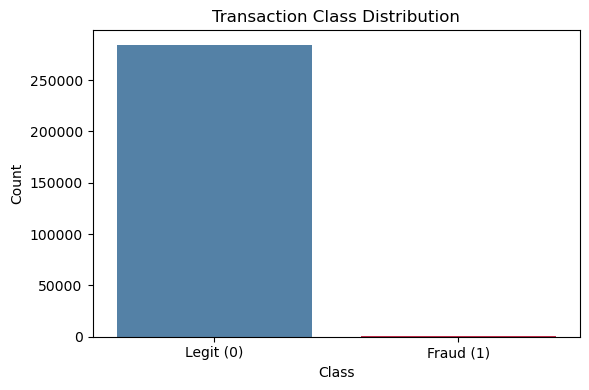

Fraud-to-legit ratio: 1 fraud per 578 legit transactions


In [3]:
# what is distribution of fraud and not fraud?
df['hour'] = (df['Time'] // 3600) % 24
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Transaction Class Distribution')
plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()

print("Fraud-to-legit ratio: 1 fraud per", round(284315/492), "legit transactions")

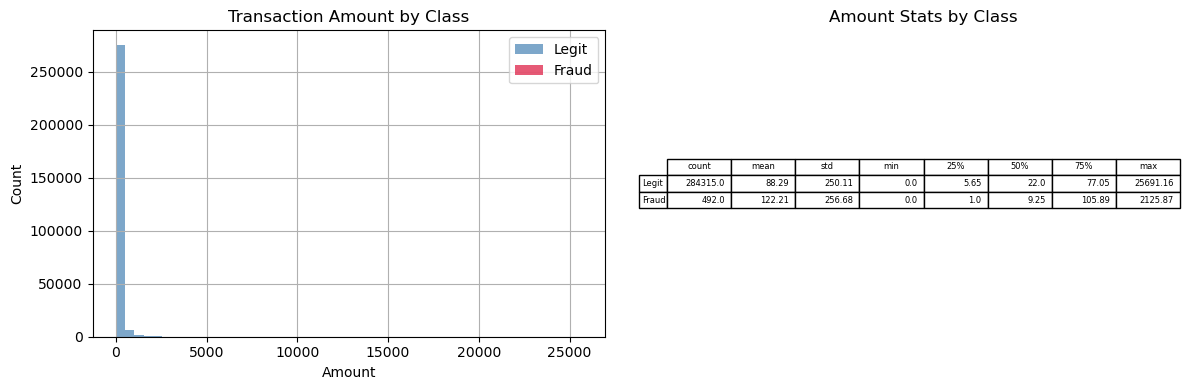

In [4]:
# Do fraud transactions have different amounts than real ones?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount distribution by class
axes[0].set_title('Transaction Amount by Class')
df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='steelblue', alpha=0.7, label='Legit')
df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[0], color='crimson', alpha=0.7, label='Fraud')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].legend()

# Summary stats side by side
axes[1].axis('off')
summary = df.groupby('Class')['Amount'].describe().round(2)
axes[1].table(cellText=summary.values,
              rowLabels=['Legit', 'Fraud'],
              colLabels=summary.columns,
              loc='center')
axes[1].set_title('Amount Stats by Class')

plt.tight_layout()
plt.savefig('../outputs/figures/amount_distribution.png', dpi=150)
plt.show()

- Legit mean: $88.29 vs Fraud mean: $122.21: fraud transactions are slightly higher on average

- Fraud max is $2,125 vs legit max of $25,691: fraud transactions actually avoid huge amounts, probably to stay under the radar

- Fraud 75th percentile is $105 vs legit's $77: fraud clusters in a mid-range sweet spot



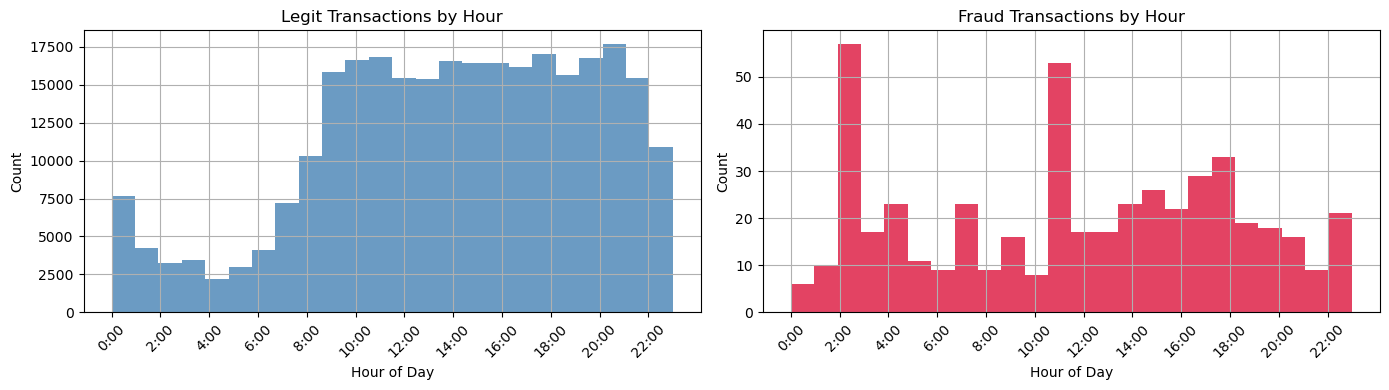

In [5]:
# What times does fraud typically occur?

# Convert Time (seconds) to hours
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['Class'] == 0]['hour'].hist(bins=24, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Legit Transactions by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xticklabels([f'{h}:00' for h in range(0, 24, 2)], rotation=45)

df[df['Class'] == 1]['hour'].hist(bins=24, ax=axes[1], color='crimson', alpha=0.8)
axes[1].set_title('Fraud Transactions by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xticklabels([f'{h}:00' for h in range(0, 24, 2)], rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/time_distribution.png', dpi=150)
plt.show()

Fraud spikes at 2am and 11pm

In [6]:
import sys
sys.path.append('../src')
from features import engineer_features

df_features = engineer_features(df)
print(df_features.shape)
df_features.head()

(284807, 33)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Class,hour,is_night,amount_log,amount_zscore
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,1,5.014760,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,1,1.305626,-0.342474
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0,1,5.939276,1.160684
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0,1,4.824306,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0,1,4.262539,-0.073403


In [7]:
from model import get_data_splits, train_logistic_regression, train_isolation_forest

X_train, X_test, y_train, y_test = get_data_splits(df_features)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud in test set:", y_test.sum())

Train size: (227845, 32)
Test size: (56962, 32)
Fraud in test set: 98


In [8]:
# training models 

lr_model, scaler = train_logistic_regression(X_train, y_train)
iso_model = train_isolation_forest(X_train)



In [9]:
# predictions

from sklearn.preprocessing import StandardScaler

X_test_scaled = scaler.transform(X_test)

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

iso_preds = iso_model.predict(X_test)
iso_preds = np.where(iso_preds == -1, 1, 0)
iso_preds_fixed = (iso_preds == -1).astype(int)


In [10]:
# accuracies of models 

from sklearn.metrics import classification_report, roc_auc_score

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['Legit', 'Fraud']))
print("ROC-AUC:", roc_auc_score(y_test, lr_probs).round(4))

print("=" * 50)
print("ISOLATION FOREST")
print("=" * 50)
print(classification_report(y_test, iso_preds_fixed, target_names=['Legit', 'Fraud']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9716
ISOLATION FOREST
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


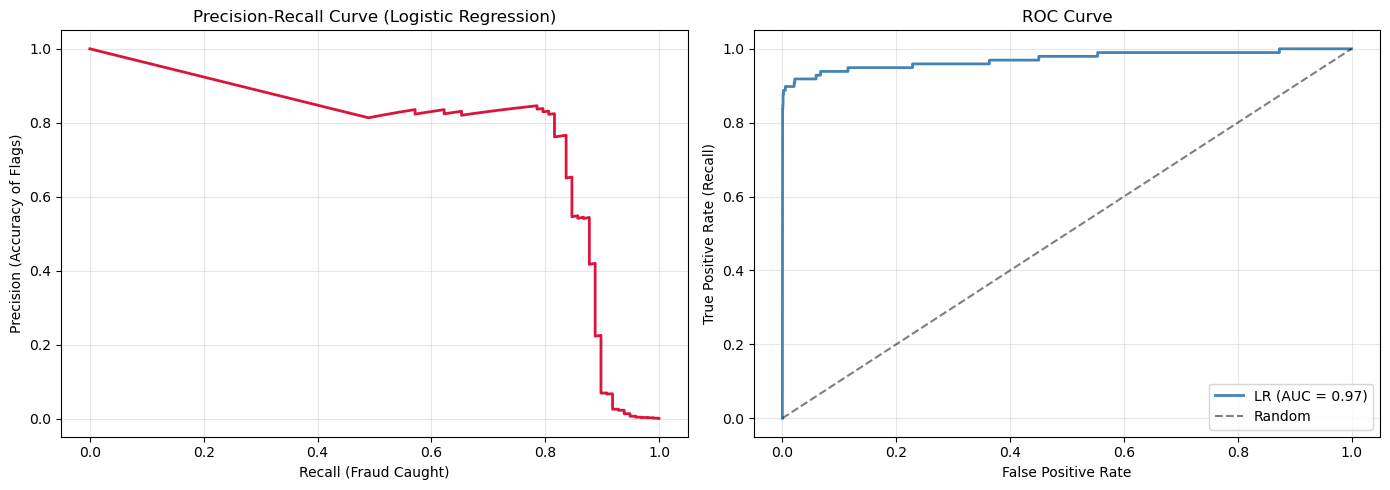

In [11]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, lr_probs)
axes[0].plot(recall, precision, color='crimson', lw=2)
axes[0].set_xlabel('Recall (Fraud Caught)')
axes[0].set_ylabel('Precision (Accuracy of Flags)')
axes[0].set_title('Precision-Recall Curve (Logistic Regression)')
axes[0].grid(True, alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_probs)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label='LR (AUC = 0.97)')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/model_evaluation.png', dpi=150)
plt.show()

In [12]:
# Business Summary

threshold = np.percentile(lr_probs, 99)

high_risk = X_test.copy()
high_risk['actual'] = y_test.values
high_risk['fraud_prob'] = lr_probs
high_risk['flagged'] = (lr_probs >= threshold).astype(int)

flagged = high_risk[high_risk['flagged'] == 1]

print("=" * 50)
print("BUSINESS SIMULATION: Flag top 1% highest-risk transactions")
print("=" * 50)
print(f"Total transactions reviewed:  {len(flagged)}")
print(f"Fraud cases caught:           {flagged['actual'].sum()}")
print(f"Legit transactions flagged:   {(flagged['actual'] == 0).sum()}")
print(f"Fraud catch rate:             {flagged['actual'].sum() / y_test.sum():.1%}")
print(f"Precision of flags:           {flagged['actual'].sum() / len(flagged):.1%}")

BUSINESS SIMULATION: Flag top 1% highest-risk transactions
Total transactions reviewed:  570
Fraud cases caught:           88
Legit transactions flagged:   482
Fraud catch rate:             89.8%
Precision of flags:           15.4%


In [13]:
import sys
sys.path.append('../src')
from evaluate import save_models

save_models(lr_model, scaler, iso_model)

Models saved.


In [14]:
# for streamlit dash

df_sample = df.sample(n=10000, random_state=42)
df_sample.to_csv('../data/sample.csv', index=False)